# Exploratory Analysis of Kamloops Transit Performance

This notebook examines when and where schedule deviations occur in the cleaned six-month dataset. The primary measure is `on_time_performance_deviation_seconds`, which equals actual event time minus scheduled event time. Negative values are early and positive values are late.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.run_eda import run_eda

INPUT = PROJECT_ROOT / 'data' / 'processed' / 'transit_events_clean.parquet'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

## Generate the analytical summaries

The workflow uses all records with a measured performance deviation. It generates compact aggregate tables rather than exporting the complete event-level dataset.

In [2]:
tables = run_eda(INPUT, TABLE_DIR, FIGURE_DIR)
overall = tables['eda_overall_summary.csv']
overall.T

,0
total_clean_records,3621203.000
performance_records,3618099.000
departure_delay_records,3470591.000
after_midnight_records,72830.000
mean_deviation_seconds,107.465
median_deviation_seconds,82.000
p90_deviation_seconds,303.000
p95_deviation_seconds,405.000
early_percent,9.676
on_time_percent,65.453


The analysis includes 3,618,099 measured events. Median deviation is 82 seconds late, and the 95th percentile is 405 seconds (6.75 minutes) late. The mean is higher than the median, indicating that the late side of the distribution contains a longer tail.

## How are official status categories distributed?

,status,records,percent
0,Very Early,71658,1.981
1,Early,278416,7.695
2,On Time,2368167,65.453
3,Late,657784,18.18
4,Very Late,242074,6.691


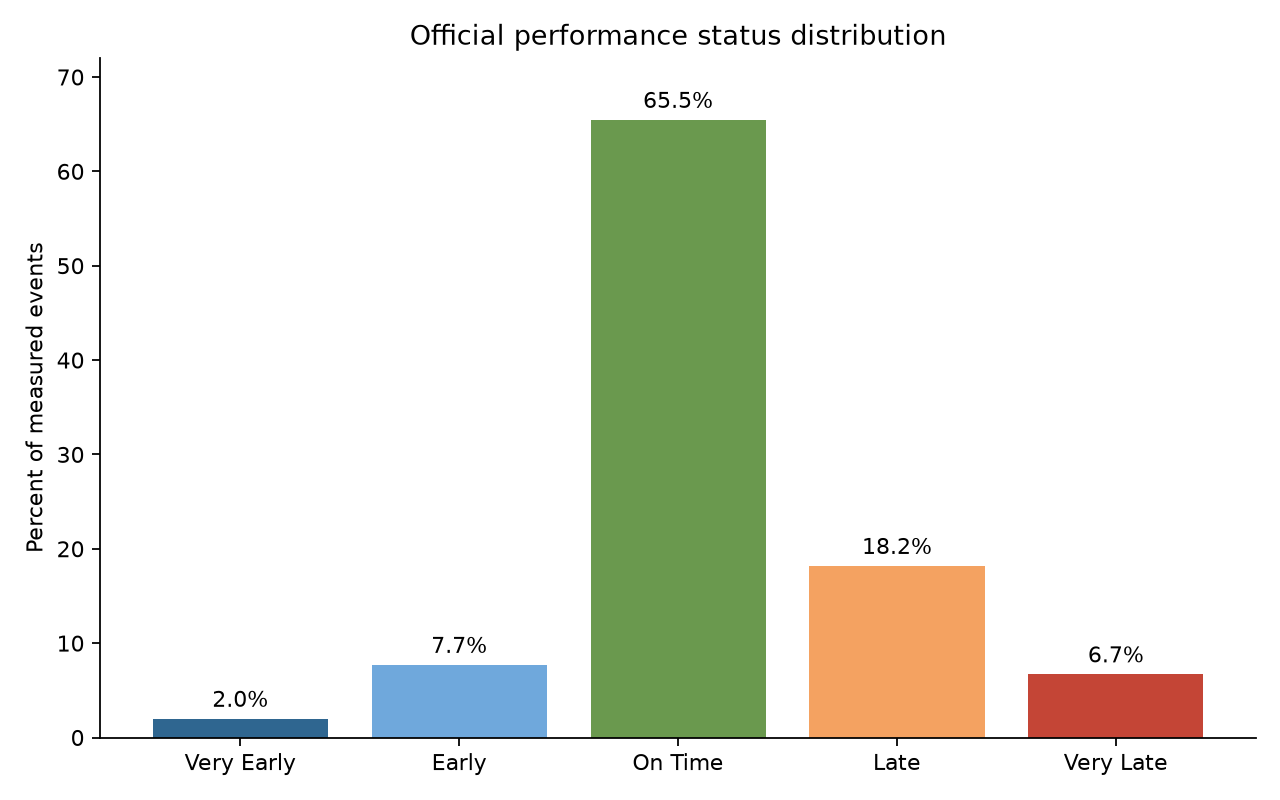

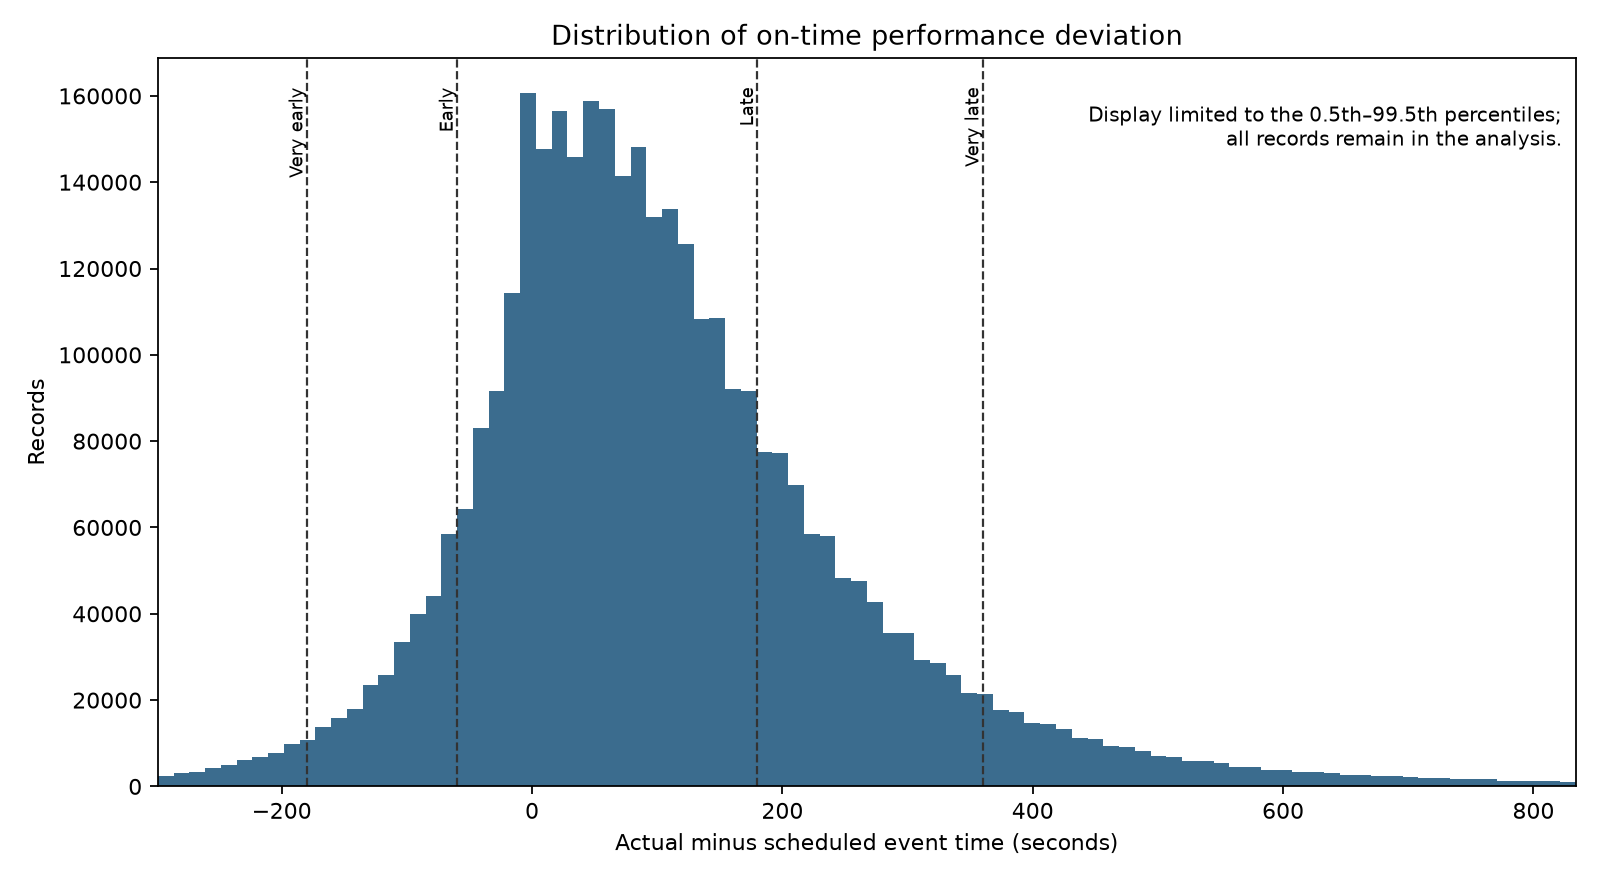

In [3]:
display(tables['eda_status_summary.csv'])
display(Image(filename=FIGURE_DIR / 'eda_status_distribution.png'))
display(Image(filename=FIGURE_DIR / 'eda_delay_distribution.png'))

Official On Time events account for 65.453% of measured records. Late and Very Late together account for 24.871%, while Early and Very Early account for 9.676%. The histogram is right-skewed: most events are near the on-time range, but some late deviations extend much farther from the centre. The displayed histogram limits are only a visual choice; the tables and calculations retain all observations.

## How does performance vary by route?

,route_name,records,median_deviation_seconds,on_time_percent,late_percent
24,81,12497,320.0,28.655,68.793
0,1,415714,110.0,59.422,32.796
2,13,53503,105.0,56.915,31.518
7,2,327177,103.0,64.664,29.055
25,9,610136,96.0,59.505,29.848


,route_name,records,median_deviation_seconds,on_time_percent,late_percent
9,4,220449,45.0,72.262,13.461
10,5,142575,49.0,78.054,13.122
3,14,84190,53.0,73.386,16.068
1,10,61238,55.0,72.212,16.047
12,7,609505,67.0,67.006,21.814


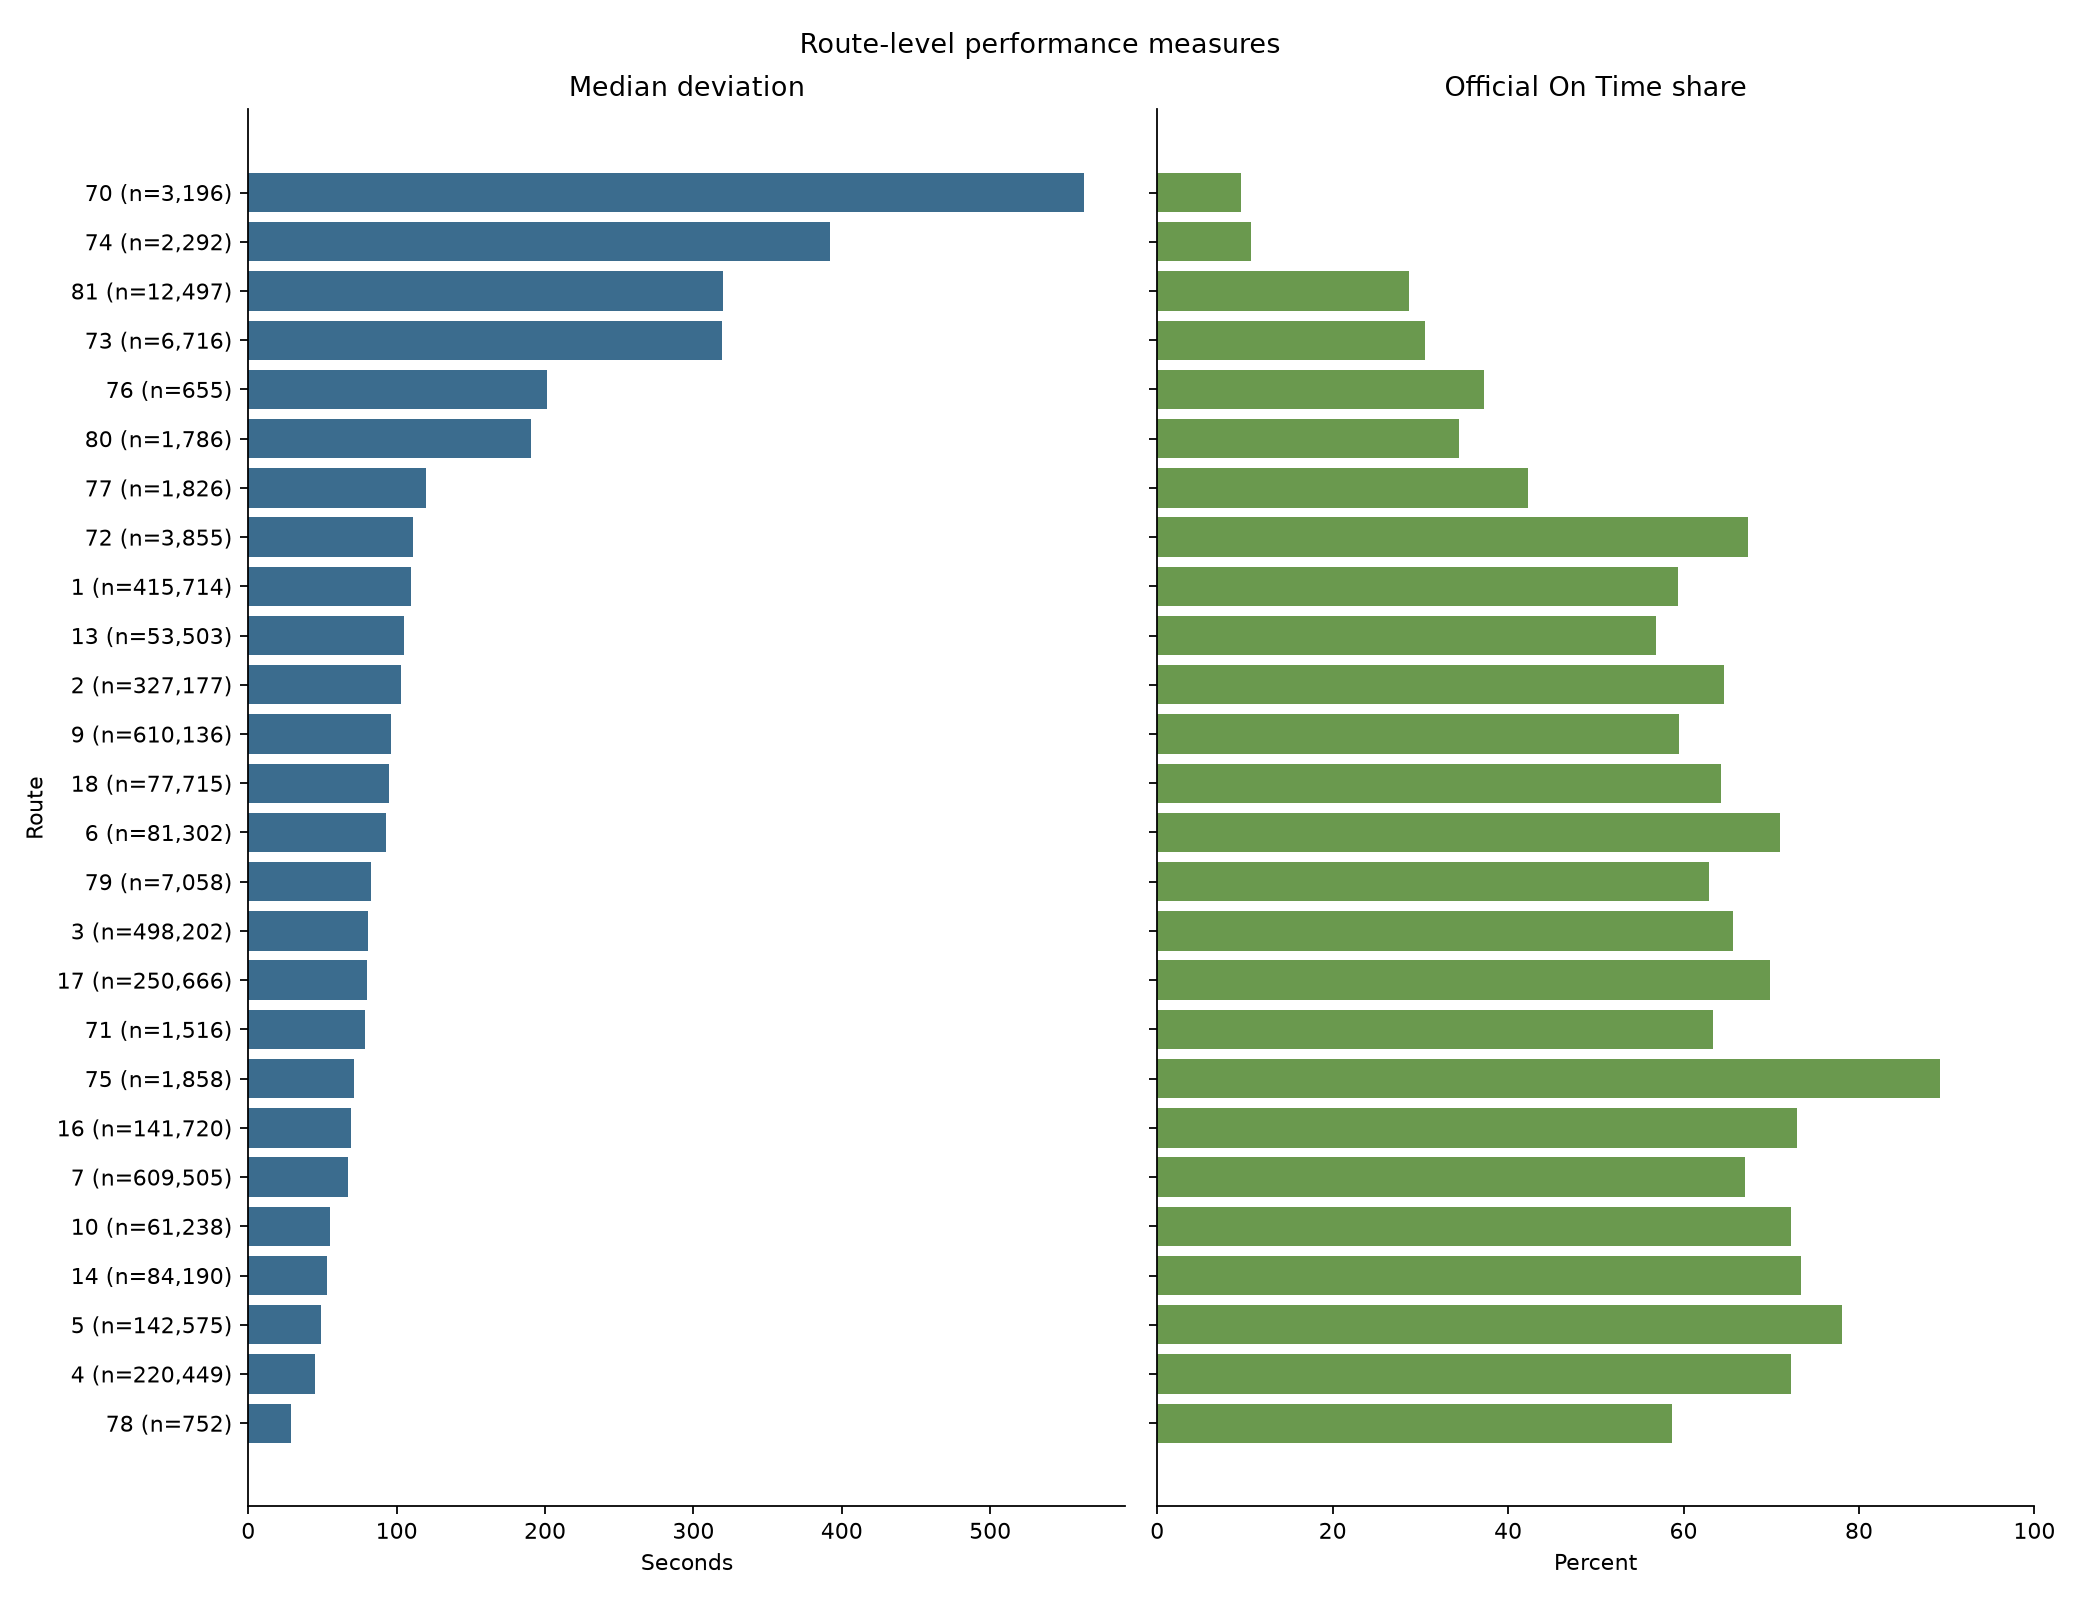

In [4]:
route = tables['eda_route_summary.csv']
high_volume_routes = route.loc[route['records'] >= 10_000]
display(high_volume_routes.nlargest(5, 'median_deviation_seconds')[['route_name', 'records', 'median_deviation_seconds', 'on_time_percent', 'late_percent']])
display(high_volume_routes.nsmallest(5, 'median_deviation_seconds')[['route_name', 'records', 'median_deviation_seconds', 'on_time_percent', 'late_percent']])
display(Image(filename=FIGURE_DIR / 'eda_route_performance.png'))

Route-level results vary substantially. Routes 70 and 74 have the highest overall medians, but each has fewer than 3,200 measured events, so their estimates are less stable than those for high-volume routes. Among routes with at least 10,000 events, Route 81 has the highest median deviation at 320 seconds and the lowest On Time share at 28.655%. Route 4 has the lowest median deviation in that high-volume group at 45 seconds, while Route 5 has the highest On Time share at 78.054%. These comparisons describe observed service records and do not identify the causes of route differences.

## How does performance change through the service day?

,scheduled_hour,records,median_deviation_seconds,on_time_percent,late_percent
0,0.0,56382,66.0,69.265,19.123
1,1.0,15926,-4.0,58.282,10.618
2,2.0,452,-82.0,25.221,21.903
3,5.0,3688,57.0,65.049,20.418
4,6.0,120653,66.0,74.508,19.187
5,7.0,237543,71.0,71.785,20.393
6,8.0,266867,95.0,63.946,28.528
7,9.0,231240,76.0,70.813,20.915
8,10.0,214406,76.0,68.681,22.051
9,11.0,196371,83.0,65.603,25.062


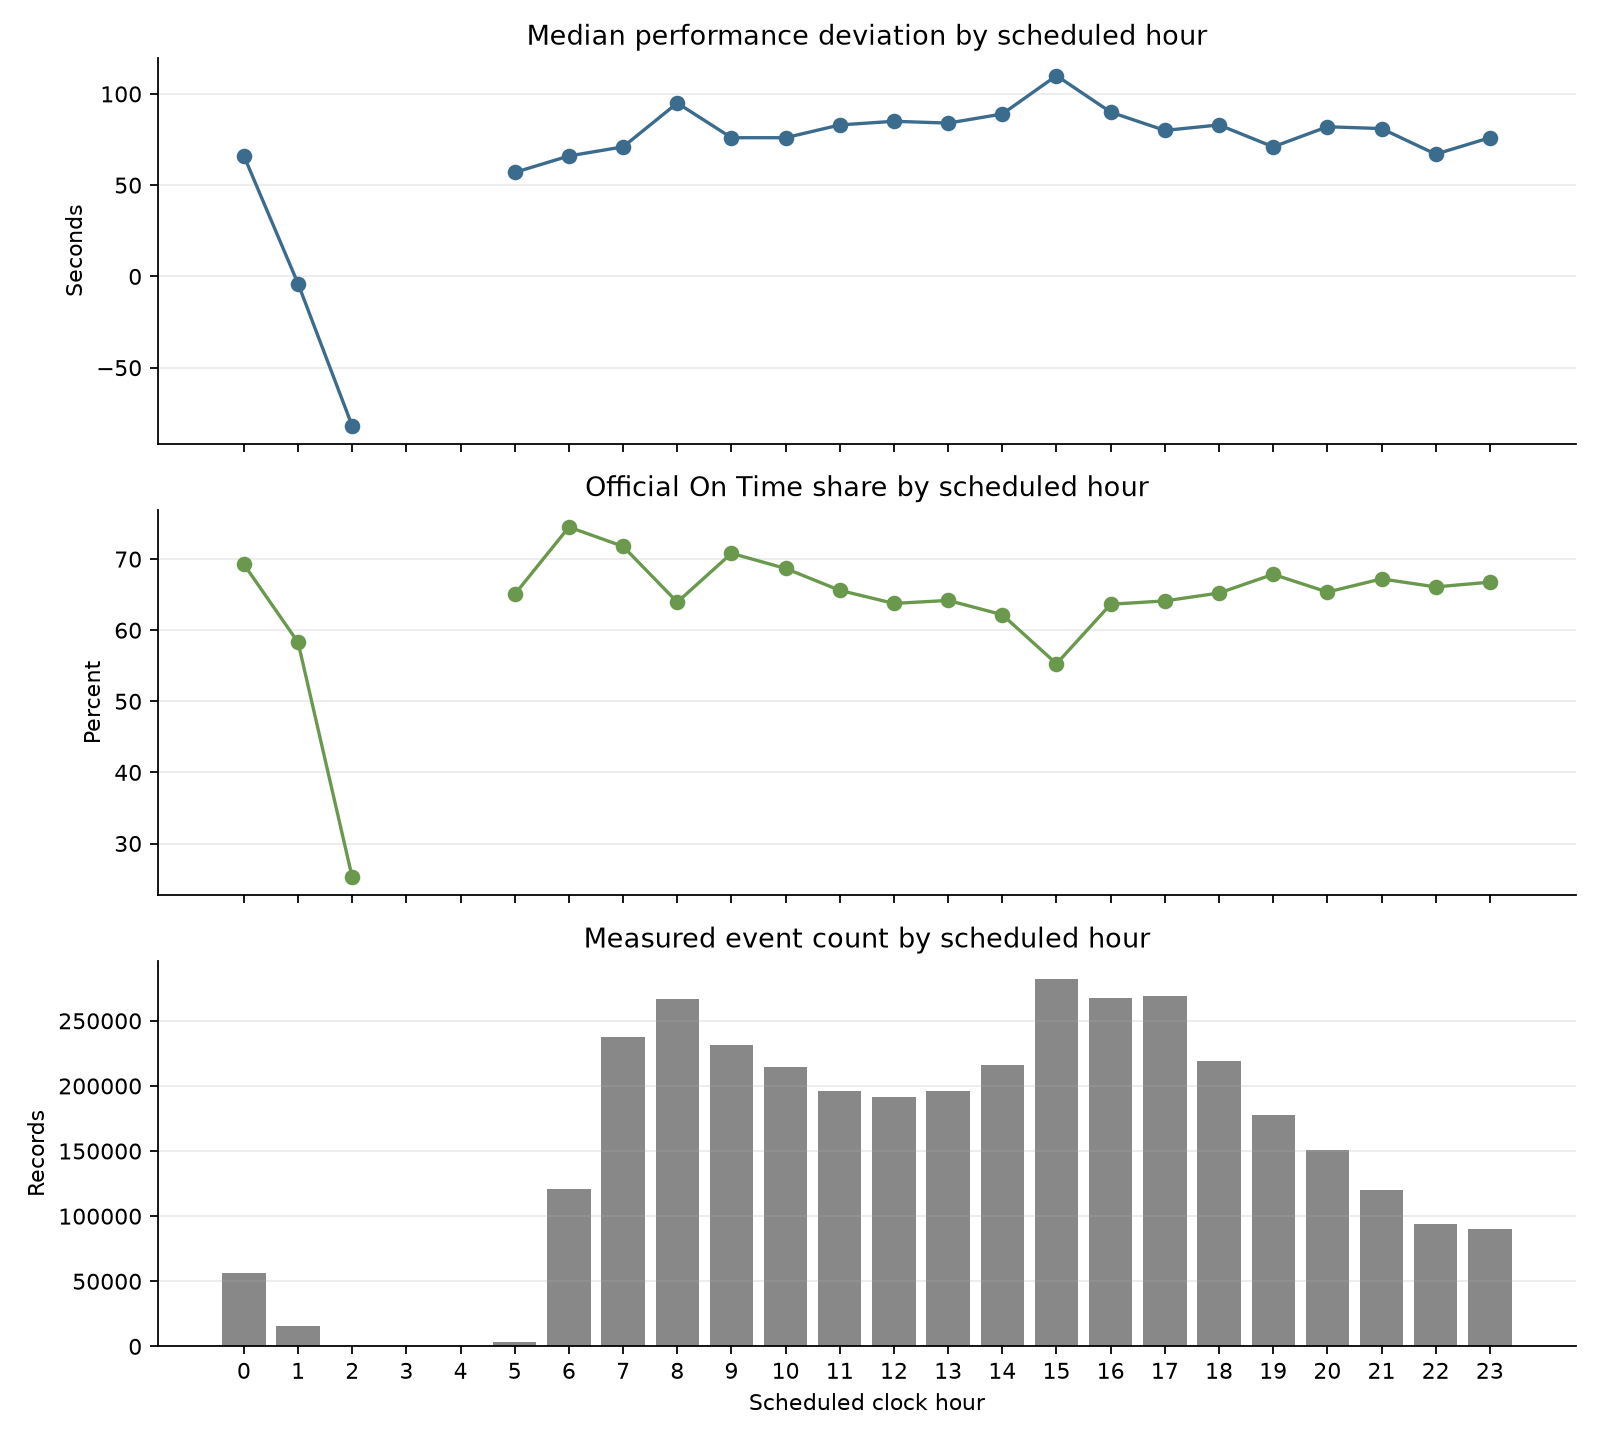

In [5]:
hourly = tables['eda_hourly_summary.csv']
display(hourly[['scheduled_hour', 'records', 'median_deviation_seconds', 'on_time_percent', 'late_percent']])
display(Image(filename=FIGURE_DIR / 'eda_hourly_pattern.png'))

The 15:00 hour has the highest median deviation among well-represented hours at 110 seconds and the lowest daytime On Time share at 55.280%. The 06:00 hour has the highest On Time share at 74.508%. Hours 03:00 and 04:00 contain no scheduled events, while 02:00 contains only 452 records; overnight percentages therefore require caution. Clock-hour values are analyzed exactly as supplied, without converting the timestamps to another timezone.

## Are weekday, weekend, and monthly patterns different?

,period_group,records,median_deviation_seconds,p95_deviation_seconds,on_time_percent,late_percent
0,Weekday,2924163,75.0,383.0,66.650,23.075
1,Weekend,693936,111.0,476.0,60.409,32.440


,weekday,records,median_deviation_seconds,on_time_percent,late_percent
0,Monday,573292,64.0,68.124,19.948
1,Tuesday,604293,76.0,66.485,23.298
2,Wednesday,576779,80.0,65.917,24.381
3,Thursday,585492,82.0,65.863,24.820
4,Friday,584307,76.0,66.889,22.872
5,Saturday,417616,97.0,62.203,29.142
6,Sunday,276320,132.0,57.698,37.425


,month,records,median_deviation_seconds,on_time_percent,late_percent
0,January,618440,61.0,66.306,19.863
1,February,561340,79.0,66.376,23.879
2,March,637615,76.0,65.473,23.976
3,April,604015,96.0,61.203,29.578
4,May,598229,93.0,65.739,26.951
5,June,598460,88.0,67.690,25.101


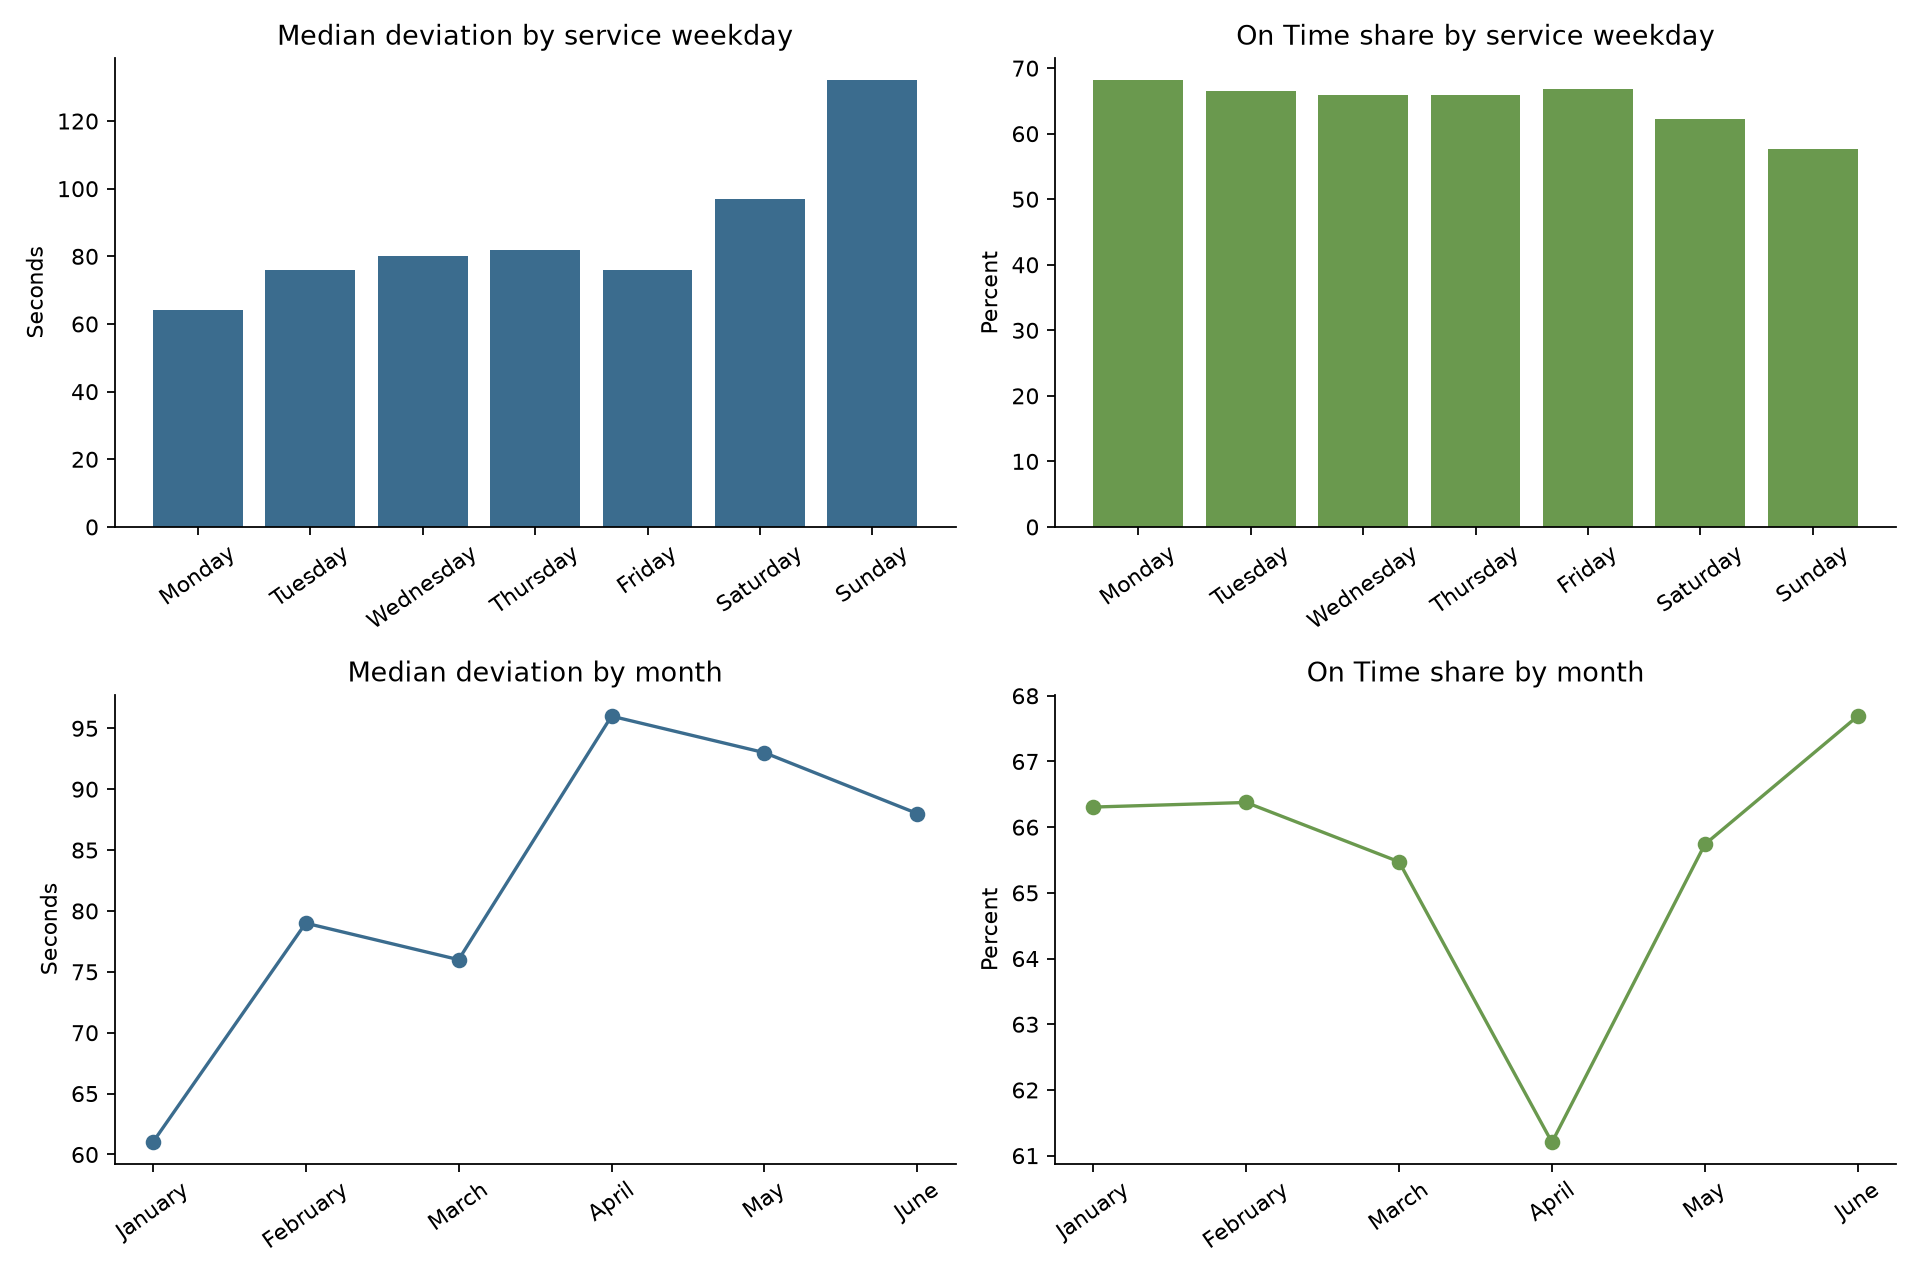

In [6]:
display(tables['eda_period_summary.csv'][['period_group', 'records', 'median_deviation_seconds', 'p95_deviation_seconds', 'on_time_percent', 'late_percent']])
display(tables['eda_weekday_summary.csv'][['weekday', 'records', 'median_deviation_seconds', 'on_time_percent', 'late_percent']])
display(tables['eda_monthly_summary.csv'][['month', 'records', 'median_deviation_seconds', 'on_time_percent', 'late_percent']])
display(Image(filename=FIGURE_DIR / 'eda_calendar_patterns.png'))

Weekend events have a median deviation of 111 seconds, compared with 75 seconds on weekdays. Their late share is also higher: 32.440% versus 23.075%. Sunday has the highest weekday median at 132 seconds and the lowest On Time share at 57.698%. Across months, April has the highest median deviation (96 seconds) and the lowest On Time share (61.203%), while June has the highest On Time share (67.690%). Changes in routes, schedules, traffic, weather, or service mix could contribute to these differences; this descriptive analysis cannot isolate causal effects.

## Which stops show notable delay levels?

,stop_id,stop_name,records,median_deviation_seconds,p95_deviation_seconds,on_time_percent
402,104639,Old Highway 5 at Devick Rd,1706,220.0,623.50,40.797
386,104620,Halston Connector Rd at Salish Rd,1528,208.0,499.30,37.762
385,104619,Halston Ave at Kingston Ave,1526,192.0,483.00,43.906
401,104638,Old Highway 5 at Mattoch-McKeague Rd,1706,184.0,589.50,48.769
41,104254,Tranquille Rd at Yew St S,8206,180.0,569.00,45.942
283,104509,Columbia St W at Bluff Pl,10494,179.0,451.35,49.657
581,151040,Tranquille Rd at 8th St,8053,179.0,433.40,50.217
565,151021,1000 Blk Ricardo Rd,2349,176.0,518.20,49.638
570,151026,Okanagan Way at Dene Dr,1926,173.0,513.00,50.208
528,104770,Mattoch-McKeague Rd at Cameron Rd,1707,172.0,495.00,51.845


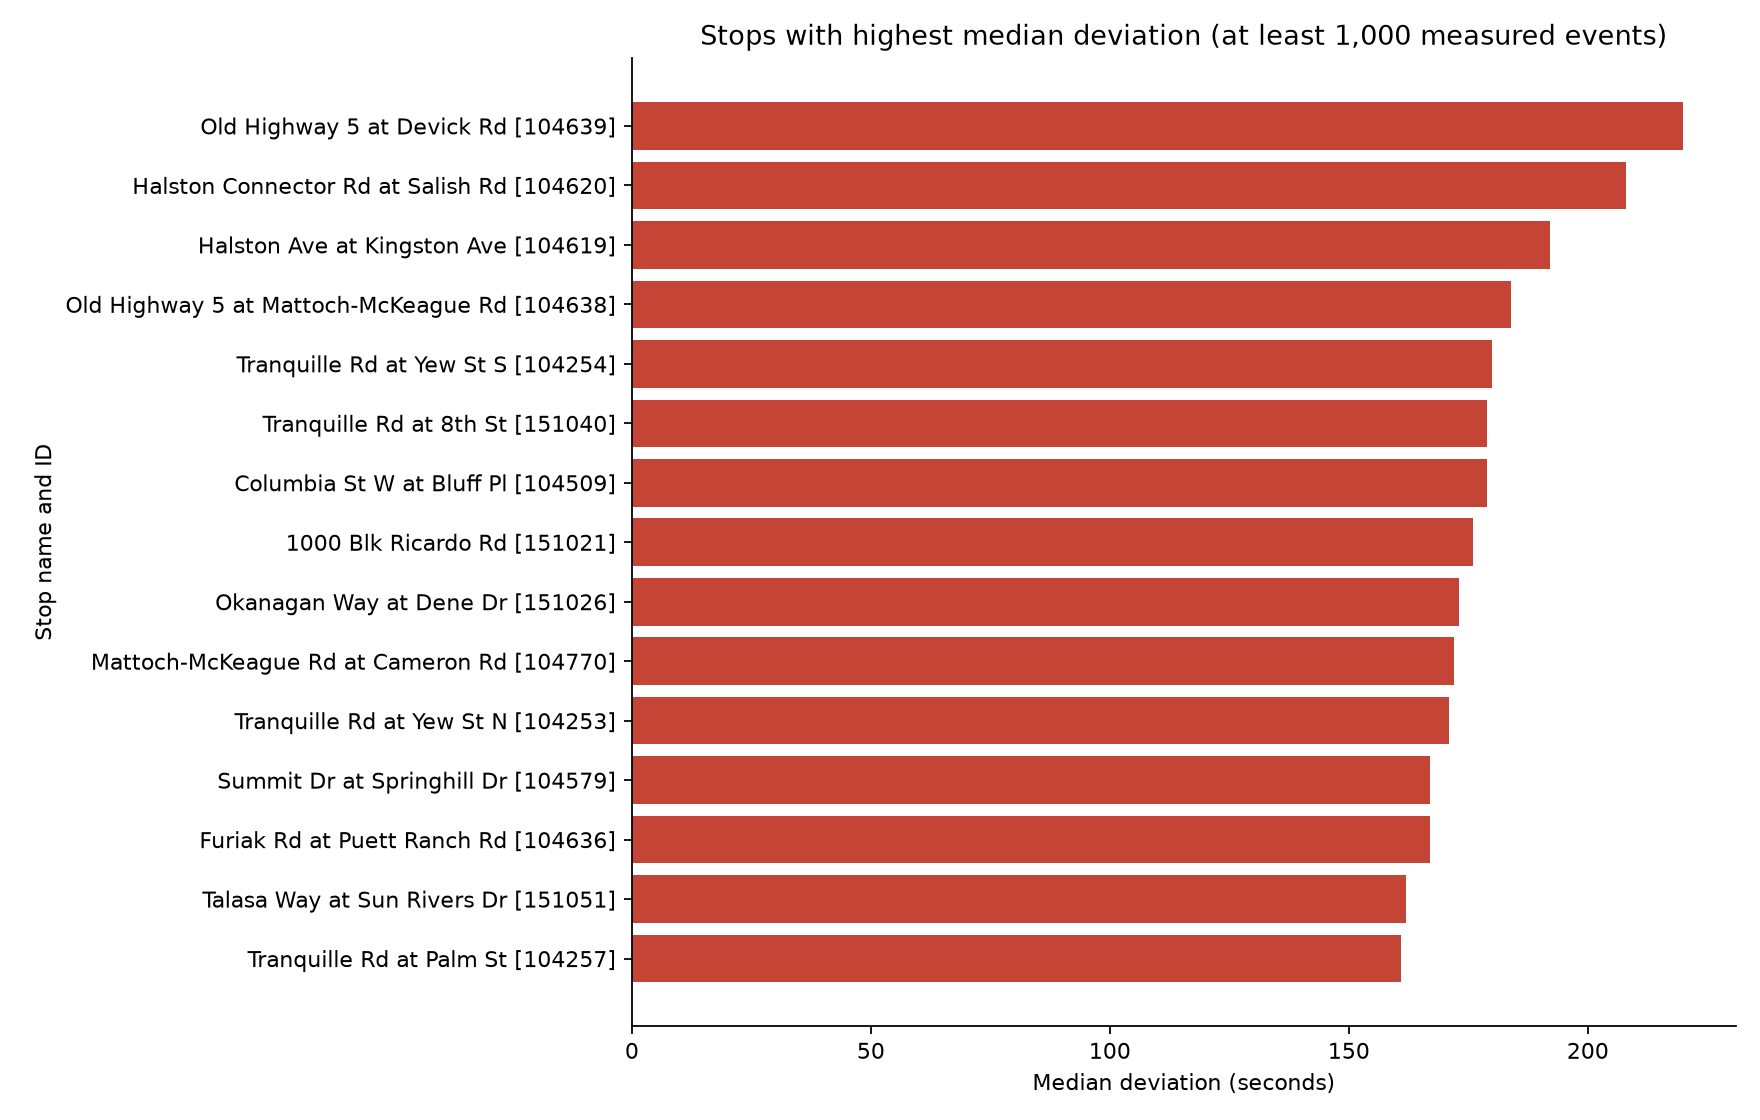

In [7]:
stops = tables['eda_stop_summary.csv']
eligible_stops = stops.loc[stops['records'] >= 1_000]
display(eligible_stops.nlargest(15, 'median_deviation_seconds')[['stop_id', 'stop_name', 'records', 'median_deviation_seconds', 'p95_deviation_seconds', 'on_time_percent']])
display(Image(filename=FIGURE_DIR / 'eda_stop_patterns.png'))

Among stops with at least 1,000 measured events, Old Highway 5 at Devick Road (stop 104639) has the highest median deviation at 220 seconds. Several high-median stops occur along Old Highway 5, Halston, and Tranquille corridors. Stop summaries can reflect the routes serving each location and a delay accumulated earlier in a trip; they should not be interpreted as evidence that a particular stop causes delays. The 1,000-event threshold reduces emphasis on very small samples.

## How do arrival-type and departure-type records differ?

In [8]:
tables['eda_event_type_summary.csv']

,event_type,records,mean_deviation_seconds,median_deviation_seconds,std_deviation_seconds,p90_deviation_seconds,p95_deviation_seconds,early_percent,on_time_percent,late_percent
0,arrival,147464,9.297,-4.0,245.592,258.0,382.0,34.421,49.559,16.021
1,departure,3470635,111.637,84.0,168.593,304.0,405.0,8.624,66.129,25.247


Arrival-type records have a median deviation of -4 seconds, compared with 84 seconds for departure-type records. Arrival records form only 147,464 measured events and represent a structurally different subset of stop events, so this difference should not be treated as a direct comparison of arrivals and departures from the same trips. The unusable `trip_id` prevents reliable within-trip pairing.

## Limitations

The results are descriptive associations. Route and time groups differ in service volume and composition, and the data contain no reliable trip identifier. Weather, traffic, ridership, incidents, and other external conditions are not present. The supplied timestamps carry a UTC marker, but their operational timezone meaning is undocumented; time-of-day results therefore use the displayed clock values without timezone conversion. Extreme observations remain included, and sparse route or overnight groups are interpreted cautiously.